In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [3]:
dust_values = {
    'MW': 0.5968,
    'SMC': 0.7193,
    'stellar': 0.3064
}

def predict_Av(f, Sigma_SFR, sini, Zgas, add_noise=True):
    
    c = [0.428, 0.00967, 0.953, 0.00383, 1.51, 1.68, 800.0, 4.75]
    sigma = 0.221

    pred = c[0] - c[1] / (np.log10(c[2] * sini)) - c[3] / np.log10(c[4] * f) - c[5] * (c[6] * Sigma_SFR)**(-c[7] * Zgas)

    if add_noise:
        pred += np.random.normal(0, sigma, size=pred.shape)

    pred = np.clip(pred, -5.0, 2.0)

    return np.array(10 ** pred)

def predict_B0(f, Av, B1s, B3, dust_mixture='MW', add_noise=True):

    if dust_mixture == 'MW':
        c = [0.662, 0.224, 0.327, 13.8, 1.53, 23.7, 0.112]
        sigma = 0.072
        pred = c[0] * B1s + c[1] * B3 - c[2] / B3 * (c[3] * B1s + c[4] * B3 + (c[5] * Av) ** (c[6] * B3))
    elif dust_mixture in ['SMC', 'stellar']:
        c = [0.0413, 5.79, 10.2, 3.78, 5.13, 7.2, 0.379, 0.127, 2.91]
        sigma = 0.216
        pred = c[0] * B3 * (c[1] * Av + (c[2] * Av)**(c[3]*B1s) - c[4] * np.log10(c[5] * B3) + (c[6] * f)**(-c[7] * B3)) - c[8]
    else:
        raise ValueError(f'Unknown dust mixture: {dust_mixture}')
    
    if add_noise:
        pred += np.random.normal(0, sigma, size=pred.shape)

    pred = np.clip(pred, -5.0, 2.0)

    return np.array(10 ** pred)

def predict_B1s(f, Av, Zgas, sini, log10Mstar, add_noise=True):

    c = [0.0324, 25.5, 2.36, 0.00411, 1.95]
    sigma = 0.058
    pred = c[0] / Av * ((c[1] * Zgas)**(c[2] * sini) - c[3] * log10Mstar / np.log10(c[4] * f))

    if add_noise:
        pred += np.random.normal(0, sigma, size=pred.shape)

    pred = np.clip(pred, -1.0, 1.0)

    return np.array(pred)

def predict_B2s(f, B0, B1s, add_noise=True):

    c = [0.264, 0.129, 0.00351, 0.776, 1.29, 5.93, 179.0]
    sigma = 0.381
    pred = c[0] * B0 + c[1] - f * (c[2] * B0**(-c[3]) + c[4] * B1s * (c[5] * B1s + np.log10(c[6] * B0)))

    if add_noise:
        pred += np.random.normal(0, sigma, size=pred.shape)

    pred = np.clip(pred, -5.0, 5.0)

    return np.array(pred)

# def predict_B3(f, Av, Zgas, log10Mstar, log10Mgas, add_noise=True):

#     c = [4.11, 0.567, 1.15, 5.25, 1.46, 0.713] 
#     sigma = 0.762
#     pred = c[0] * f - c[1] + c[2] * (c[3] * Zgas) ** (c[4] * Av) * (log10Mstar - c[5] * log10Mgas)

#     if add_noise:
#         pred += np.random.normal(0, sigma, size=pred.shape)

#     pred = np.clip(pred, 3.e-2, 10.0)

#     return np.array(pred)

def predict_B3(f, Av, Zgas, add_noise=True):

    c = [28.9, 2.85, 0.155, 0.0351]
    sigma = 0.779
    pred = - (c[0] * Zgas + c[1] * f) * np.log10(c[2] * Av) - c[3] 

    if add_noise:
        pred += np.random.normal(0, sigma, size=pred.shape)

    pred = np.clip(pred, 3.e-2, 10.0)

    return np.array(pred)


def get_predictions(df, dust_mixture='MW', add_noise=True):


    Av_pred = predict_Av(f=dust_values[dust_mixture], 
                        Sigma_SFR=df['Sigma_SFR'],
                        sini=df['inclination_deg'],
                        Zgas=df['Zgas'], add_noise=add_noise)

    B1s_pred = predict_B1s(f=dust_values[dust_mixture], 
                        Av=Av_pred, 
                        Zgas=df['Zgas'], 
                        sini=np.sin(df['inclination_deg'] * np.pi / 180), 
                        log10Mstar=df['logMstar'], add_noise=add_noise)
    
    # B3_pred = predict_B3(f=dust_values[dust_mixture], 
    #                     Av=Av_pred, 
    #                     Zgas=df['Zgas'], 
    #                     log10Mstar=df['logMstar'], 
    #                     log10Mgas=df['logMgas'], add_noise=add_noise)
    B3_pred = predict_B3(f=dust_values[dust_mixture], 
                         Av=Av_pred, 
                         Zgas=df['Zgas'], 
                         add_noise=add_noise)

    B0_pred = predict_B0(f=dust_values[dust_mixture], 
                        Av=Av_pred, 
                        B1s=B1s_pred, 
                        B3=B3_pred, 
                        dust_mixture=dust_mixture,
                        add_noise=add_noise)

    B2s_pred = predict_B2s(f=dust_values[dust_mixture], B0=B0_pred, B1s=B1s_pred, add_noise=add_noise)

    return Av_pred, B0_pred, B1s_pred, B2s_pred, B3_pred

In [4]:
def read_data(fname):
    
    with open(fname, "r") as fh:
        header = next(fh)
        # Remove any part of header between square brackets, as this is not a valid column name and causes problems for pandas
        header = re.sub(r'\[.*?\]', '', header)
    header = header.strip().split()
    df = pd.read_csv(fname, sep=r'\s+', names=header, comment='#', low_memory=False, skiprows=1)
    print(f"Read {len(df)} rows and {len(df.columns)} columns from {fname}")

    return df

In [5]:
def predict_A_over_Av(x, B0, B1s, B2s, B3):
    c = [0.4002, 285.6, 0.2092, 9.223, 1.016]
    B1 = 1e3 * B1s
    B2 = 1e3 * B2s
    y = (
        B0 * (np.exp(-c[1] * (x - c[0])**2) - np.exp(-c[1] * (1. - c[0])**2))
        + (B1 + B2 * (x - c[2])) * (x - c[2]) * (np.exp(-c[3] * x) - np.exp(-c[3]))
        + np.exp(B3 * (np.tanh(c[4]) - np.tanh(c[4] * x)))
    )
    return y

Read 52275 rows and 67 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_MW_los09.dat
Applying mask: 52018 rows remaining out of 52275
Read 17803 rows and 67 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_SMC_all.dat
Applying mask: 16935 rows remaining out of 17803
Read 16146 rows and 71 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_stellar_all.dat
Applying mask: 16099 rows remaining out of 16146


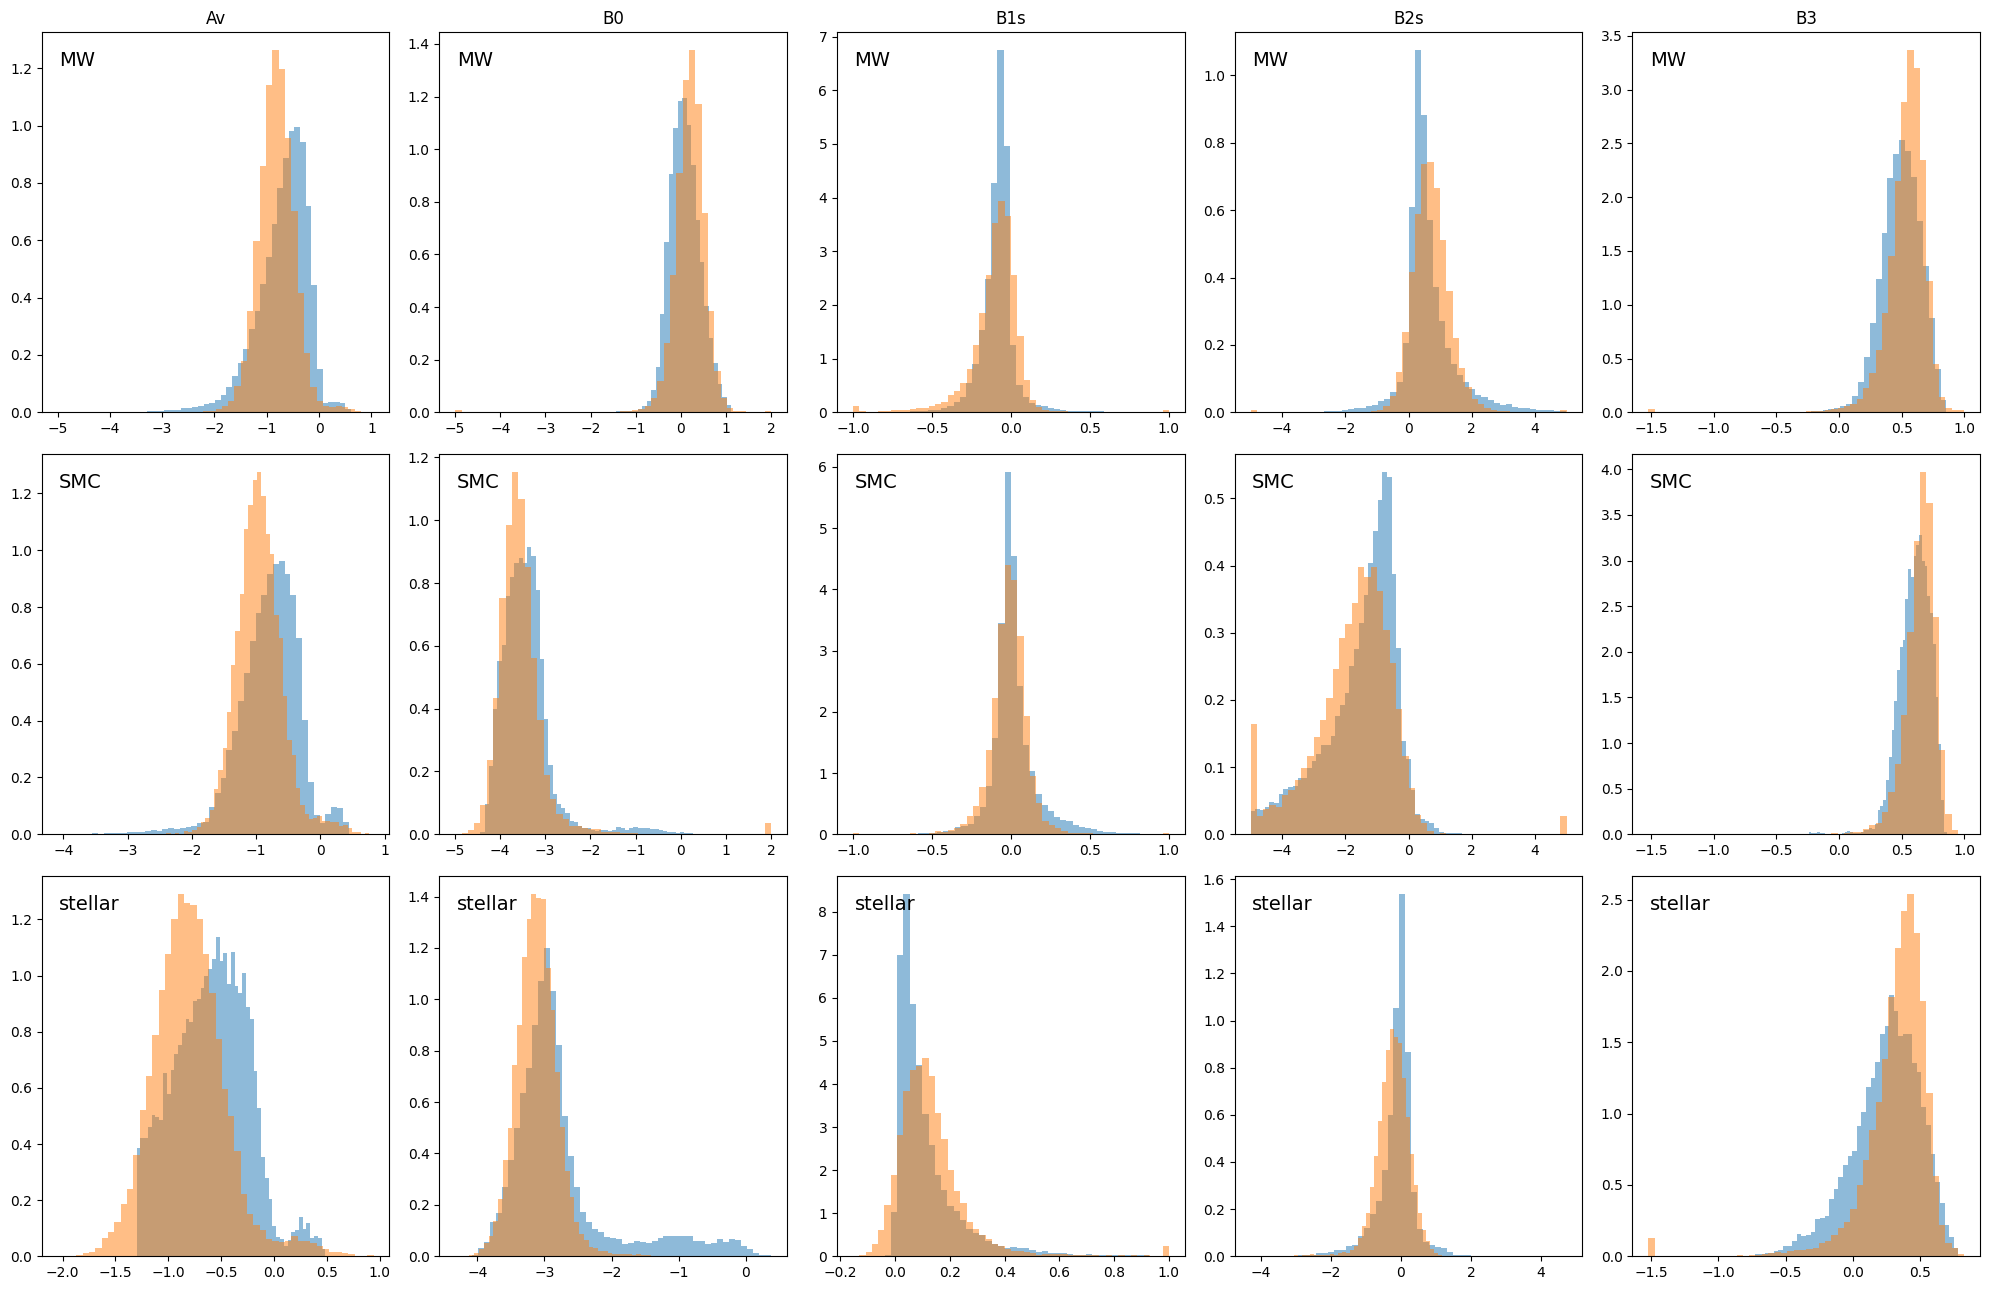

In [6]:
fig, axs = plt.subplots(3, 5, figsize=(20, 13))

all_mask = {
    'A_5542A': [1.e-5, 1.e2],
    'B_0': [1.e-5, 1.e2],
    'B_1s': [-1, 1],
    'B_2s': [-5, 5],
    'B_3': [3e-2, 10]
}

for iax, dust in enumerate(['MW', 'SMC', 'stellar']):

    if dust == 'MW':
        fname = f'../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust}_los09.dat'
    else:
        fname = f'../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust}_all.dat'
    df = read_data(fname)
    Av_true = df['A_5542A'].values

    m = np.ones(len(df), dtype=bool)
    for col, (vmin, vmax) in all_mask.items():
        m &= (df[col].values >= vmin) & (df[col].values <= vmax)
    print(f"Applying mask: {m.sum()} rows remaining out of {len(df)}")
    
    df = df[m]
    Av_true = Av_true[m]

    Av_pred, B0_pred, B1s_pred, B2s_pred, B3_pred = get_predictions(df, dust_mixture=dust, add_noise=True)

    axs[iax, 0].hist(np.log10(Av_true), density=True, bins=50, alpha=0.5, color='C0', label='True')
    axs[iax, 0].hist(np.log10(Av_pred), density=True, bins=50, alpha=0.5, color='C1', label='Predicted')

    axs[iax, 1].hist(np.log10(df['B_0'].values), density=True, bins=50, alpha=0.5, color='C0', label='True')
    axs[iax, 1].hist(np.log10(B0_pred), density=True, bins=50, alpha=0.5, color='C1', label='Predicted')

    axs[iax, 2].hist(df['B_1s'].values, density=True, bins=50, alpha=0.5, color='C0', label='True')
    axs[iax, 2].hist(B1s_pred, density=True, bins=50, alpha=0.5, color='C1', label='Predicted')

    axs[iax, 3].hist(df['B_2s'].values, density=True, bins=50, alpha=0.5, color='C0', label='True')
    axs[iax, 3].hist(B2s_pred, density=True, bins=50, alpha=0.5, color='C1', label='Predicted')

    axs[iax, 4].hist(np.log10(df['B_3'].values), density=True, bins=50, alpha=0.5, color='C0', label='True')
    axs[iax, 4].hist(np.log10(B3_pred), density=True, bins=50, alpha=0.5, color='C1', label='Predicted')

    # Add text to each panel giving the dust mixture
    for i in range(axs.shape[1]):
        axs[iax, i].text(0.05, 0.95, dust, transform=axs[iax, i].transAxes, fontsize=14, verticalalignment='top')


axs[0, 0].set_title('Av')
axs[0, 1].set_title('B0')
axs[0, 2].set_title('B1s')
axs[0, 3].set_title('B2s')
axs[0, 4].set_title('B3')

fig.tight_layout()

Read 52275 rows and 67 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_MW_los09.dat
Applying mask: 52018 rows remaining out of 52275
Read 17803 rows and 67 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_SMC_all.dat
Applying mask: 16935 rows remaining out of 17803
Read 16146 rows and 71 columns from ../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_stellar_all.dat
Applying mask: 16099 rows remaining out of 16146


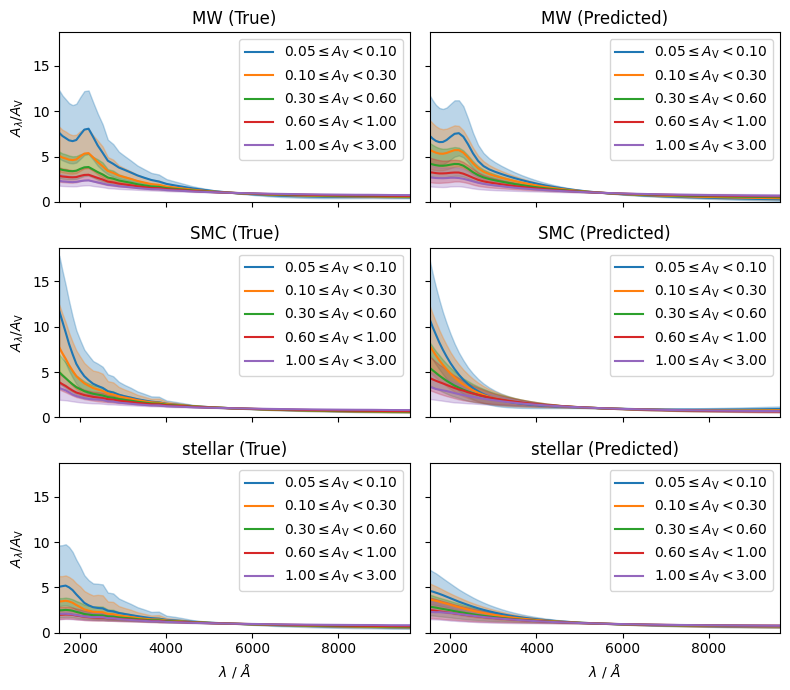

In [7]:
Av_bins = [0.05, 0.10, 0.30, 0.60, 1.00, 3.00]
fig, axs = plt.subplots(3, 2, figsize=(8, 7), sharey=True, sharex=True)
perc_low = 16
perc_high = 84

np.random.seed(42)
min_wavelength = 0
max_wavelength = 1e30

all_mask = {
    'A_5542A': [1.e-5, 1.e2],
    'B_0': [1.e-5, 1.e2],
    'B_1s': [-1, 1],
    'B_2s': [-5, 5],
    'B_3': [3e-2, 10]
}

for iax, dust in enumerate(['MW', 'SMC', 'stellar']):

    if dust == 'MW':
        fname = f'../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust}_los09.dat'
    else:
        fname = f'../data/deg_final_maybe/iob_codes_plus_Acurve_galprop_{dust}_all.dat'
    df = read_data(fname)

    m = np.ones(len(df), dtype=bool)
    for col, (vmin, vmax) in all_mask.items():
        m &= (df[col].values >= vmin) & (df[col].values <= vmax)
    print(f"Applying mask: {m.sum()} rows remaining out of {len(df)}")
    
    df = df[m]

    # get all wavelengths and true curves
    wavelength_names =  sorted(set(col for col in df.columns if col.startswith('A_')))

    # Get median curve for each galaxy_id
    # Av_true =  df.groupby('galaxy_id').first()['A_5542A'].values
    Av_true = df['A_5542A'].values
    df[wavelength_names] = df[wavelength_names].div(df['A_5542A'], axis=0)
    # A_over_Av_median = df.groupby('galaxy_id')[wavelength_names].median()
    A_over_Av_median = df[wavelength_names].values

    # get predictions
    wavelengths = np.array([col.split('_')[1][:-1] for col in wavelength_names], dtype=float)
    lambda_V = 5542
    x = wavelengths / lambda_V
    # df = df.groupby('galaxy_id').first()

    # Predict curves
    Av_pred, B0_pred, B1s_pred, B2s_pred, B3_pred = get_predictions(df, dust_mixture=dust, add_noise=True)
    df[wavelength_names] = predict_A_over_Av(x[None,:], B0_pred[:,None], B1s_pred[:,None], B2s_pred[:,None], B3_pred[:,None])
    # A_over_Av_pred = df.groupby('galaxy_id')[wavelength_names].median()
    A_over_Av_pred = df[wavelength_names].values


    for i in range(len(Av_bins)-1):

        mask = (Av_true >= Av_bins[i]) & (Av_true < Av_bins[i+1])
        y_median = np.median(A_over_Av_median[mask], axis=0)
        y_lower = np.percentile(A_over_Av_median[mask], perc_low, axis=0)
        y_upper = np.percentile(A_over_Av_median[mask], perc_high, axis=0)
        axs[iax, 0].fill_between(wavelengths, y_lower, y_upper, alpha=0.3, color=f'C{i}')
        axs[iax, 0].plot(wavelengths, y_median, color=f'C{i}', label=r'$%.2f \leq A_{\rm V} < %.2f$' % (Av_bins[i], Av_bins[i+1]))

        mask = (Av_pred >= Av_bins[i]) & (Av_pred < Av_bins[i+1])
        y_median = np.median(A_over_Av_pred[mask], axis=0)
        y_lower = np.percentile(A_over_Av_pred[mask], perc_low, axis=0)
        y_upper = np.percentile(A_over_Av_pred[mask], perc_high, axis=0)
        axs[iax, 1].fill_between(wavelengths, y_lower, y_upper, alpha=0.3, color=f'C{i}')
        axs[iax, 1].plot(wavelengths, y_median, color=f'C{i}', label=r'$%.2f \leq A_{\rm V} < %.2f$' % (Av_bins[i], Av_bins[i+1]))

        axs[iax, 0].set_title(f'{dust} (True)')
        axs[iax, 1].set_title(f'{dust} (Predicted)')

    min_wavelength = max(min_wavelength, wavelengths.min())
    max_wavelength = min(max_wavelength, wavelengths.max())

for ax in axs.flatten():
    ax.legend()
    ax.set_xlim(min_wavelength, max_wavelength)
    ax.set_ylim(0, None)
for ax in axs[-1,:]:
    ax.set_xlabel(r'$\lambda \ / \ \AA$')
for ax in axs[:,0]:
    ax.set_ylabel(r'$A_\lambda / A_{\rm V}$')
fig.align_labels()
fig.tight_layout()

fig.savefig('plots/predicted_curves.pdf', bbox_inches='tight')